In [1]:
from flowmatching import CNNModel, FlowMatcher, BetaTimeSampler, UTRGenerator
from fm_dataset import create_datasets, collate_dict_batch

In [2]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import pytorch_lightning as pl
pl.seed_everything(42)

Global seed set to 42


In [3]:
utr_type = 3
seq_length = 50 if utr_type == 5 else 240

table_path = f'../../predictor/regression_multiple/UTR{utr_type}_zscores_replicateagg.csv'

num_cell_types = 5 if utr_type == 5 else 6

device = 'cuda:0'

In [4]:
train_dataset, _, _ = create_datasets(
    utr_type=utr_type,
    table_path=table_path,
)

Loading UTR data...:   0%|          | 0/22741 [00:00<?, ?it/s]

Loading UTR data...:   0%|          | 0/2843 [00:00<?, ?it/s]

Loading UTR data...:   0%|          | 0/2842 [00:00<?, ?it/s]

In [5]:
loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=collate_dict_batch
)

In [6]:
model = CNNModel(
    input_size=4,
    hidden_dim=512,
    num_cnn_stacks=4,
    dropout=0.1,
    num_cell_types=5,
)

sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in model.buffers())

63808004

In [7]:
flow_matcher = FlowMatcher(
    model=model,
    seq_length=seq_length,
    prior_pseudocount=1,
    flow_temp=1.0,
    cls_free_noclass_ratio=0.1,
    time_sampler=BetaTimeSampler(alpha=1.4, beta=3.3),
    device=device,
)

In [8]:
loss_history = flow_matcher.run_training(
    dataloader=loader,
    max_lr=1e-3,
    num_epochs=6
)

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1066 [00:00<?, ?it/s]

  0%|          | 0/1066 [00:00<?, ?it/s]

  0%|          | 0/1066 [00:00<?, ?it/s]

  0%|          | 0/1066 [00:00<?, ?it/s]

  0%|          | 0/1066 [00:00<?, ?it/s]

  0%|          | 0/1066 [00:00<?, ?it/s]

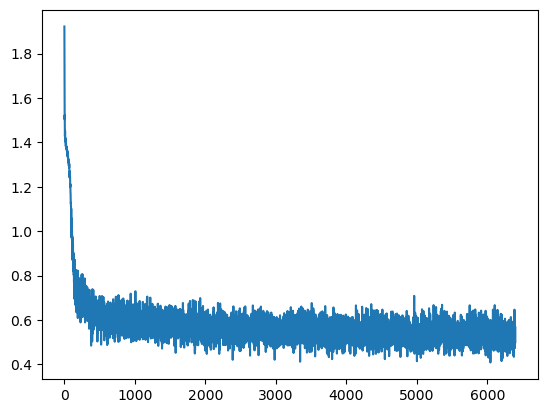

In [9]:
plt.plot(loss_history)

In [10]:
generated, x0 = flow_matcher.sample(
    num_samples=10,
    cell_type=0,
    num_integration_steps=10,
    guidance_scale=6,
    expression=2.3,
    verbose=True
)

In [ ]:
scorer = UTRGenerator(
    utr_type=utr_type,
    device='cuda:0'
)

gen_kwargs = {
    'num_integration_steps': 10,
    'guidance_scale': 4,
}

metrics, seq_table = scorer.score_generator(
    generator=flow_matcher,
    generation_method_name='sample',
    total_samples=1024 * 1000,
    batch_size=1024,
    **gen_kwargs
)
metrics

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
seq_table.to_csv(f'lfm_utr{utr_type}.csv')